In [1]:
import fsspec

fs_osn = fsspec.filesystem(
    "s3",
    profile="ocean_emulator_write",  ## This is the profile name you configured above.
)

In [2]:
fs_osn.ls("emulators/ai2_colab/2024-11-11-static-data")

['emulators/ai2_colab/2024-11-11-static-data/gaussian_grid_180_by_360.nc',
 'emulators/ai2_colab/2024-11-11-static-data/ocean_hgrid.nc',
 'emulators/ai2_colab/2024-11-11-static-data/ocean_static_no_mask_table.nc']

#### Data check

In [3]:
mapper = fs_osn.get_mapper("emulators/ai2_colab/2024-11-01-CM4-pre-industrial-control-simulation/ocean_5daily.zarr/")

import xarray as xr

ds = xr.open_zarr(mapper, consolidated=True)
ds

/tmp/ipykernel_1155661/1970563522.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_zarr(mapper, consolidated=True)


<xarray.Dataset> Size: 14TB
Dimensions:     (time: 14600, yh: 1080, xh: 1440, nv: 2, z_l: 19, xq: 1440,
                 yq: 1080, z_i: 20)
Coordinates:
  * nv          (nv) float64 16B 1.0 2.0
  * time        (time) object 117kB 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
  * xh          (xh) float64 12kB -299.7 -299.5 -299.2 ... 59.53 59.78 60.03
  * xq          (xq) float64 12kB -299.6 -299.3 -299.1 ... 59.66 59.91 60.16
  * yh          (yh) float64 9kB -80.39 -80.31 -80.23 ... 89.73 89.84 89.95
  * yq          (yq) float64 9kB -80.35 -80.27 -80.19 ... 89.78 89.89 90.0
  * z_i         (z_i) float64 160B 0.0 5.0 15.0 30.0 ... 4.5e+03 5.5e+03 6.5e+03
  * z_l         (z_l) float64 152B 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
Data variables: (12/23)
    average_DT  (time) timedelta64[ns] 117kB dask.array<chunksize=(14600,), meta=np.ndarray>
    evs         (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    hfds        (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    hflso       (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    hfsifrazil  (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    hfsso       (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    ...          ...
    tos         (time, yh, xh) float32 91GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    uo          (time, z_l, yh, xq) float64 3TB dask.array<chunksize=(10, 1, 1080, 1440), meta=np.ndarray>
    ustar       (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    vo          (time, z_l, yq, xh) float64 3TB dask.array<chunksize=(10, 1, 1080, 1440), meta=np.ndarray>
    wfo         (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
    zos         (time, yh, xh) float64 182GB dask.array<chunksize=(10, 1080, 1440), meta=np.ndarray>
Attributes:
    associated_files:  areacello: 01510101.ocean_static.nc
    grid_tile:         N/A
    grid_type:         regular
    title:             CM4_piControl_C_noBLING_H

In [19]:
old_data = xr.open_zarr(
    "/pscratch/sd/s/suryad/data/CM4_5daily_v0.4.0_preprocessed.zarr", chunks={}
)

In [4]:
with fs_osn.open('emulators/ai2_colab/2024-11-11-static-data/ocean_static_no_mask_table.nc') as f:
    ds_grid = xr.open_dataset(f).load()

areacello=ds_grid.areacello.astype("float64")

In [5]:
areacello

<xarray.DataArray 'areacello' (yh: 1080, xh: 1440)> Size: 12MB
array([[34391132.    , 34370084.    , 34349276.    , ..., 34455720.    ,
        34433952.    , 34412424.    ],
       [34544320.    , 34522828.    , 34501584.    , ..., 34610276.    ,
        34588044.    , 34566060.    ],
       [34695516.    , 34673580.    , 34651900.    , ..., 34762832.    ,
        34740144.    , 34717704.    ],
       ...,
       [  304305.3125,  1500327.    ,  2680075.5   , ...,  3269394.75  ,
         2096590.5   ,   905253.3125],
       [  304324.75  ,  1500419.875 ,  2680238.5   , ...,  3269592.75  ,
         2096719.75  ,   905310.125 ],
       [  304334.5   ,  1500466.25  ,  2680319.75  , ...,  3269691.75  ,
         2096784.375 ,   905338.5   ]])
Coordinates:
  * xh       (xh) float64 12kB -299.7 -299.5 -299.2 -299.0 ... 59.53 59.78 60.03
  * yh       (yh) float64 9kB -80.39 -80.31 -80.23 -80.15 ... 89.73 89.84 89.95
Attributes:
    long_name:      Ocean Grid-Cell Area
    units:          m2
    cell_methods:   area:sum yh:sum xh:sum time: point
    standard_name:  cell_area

In [7]:
thetao = ds["thetao"]
hfds = ds["hfds"]

In [14]:
import numpy as np
wetmask = ~np.isnan(ds.thetao.isel(time=0)).drop_vars("time")

In [17]:
# mask thetao and hfds
thetao = thetao.where(wetmask)
hfds = hfds.where(wetmask.isel(z_l=0))

In [38]:
dz = old_data.dz
dz = dz.rename({"lev":"z_l"})

In [31]:
time = 5 * 24 * 60 * 60

In [45]:
c_p = 3992  # J/(kg C)
rho_0 = 1035  # kg/m^3

OHC = (
    (thetao.isel(time=slice(None,None)) * c_p * rho_0)
    .weighted(areacello * dz)
    .sum(["xh", "yh", "z_l"])
    .compute()
)
OHC = OHC.rename("OHC")
OHC = OHC.assign_attrs(units="J")

In [46]:
hfds_int = (
    hfds.isel(time=slice(None,None)).cumsum("time").weighted(areacello).sum(["xh", "yh"]) * time
).compute()

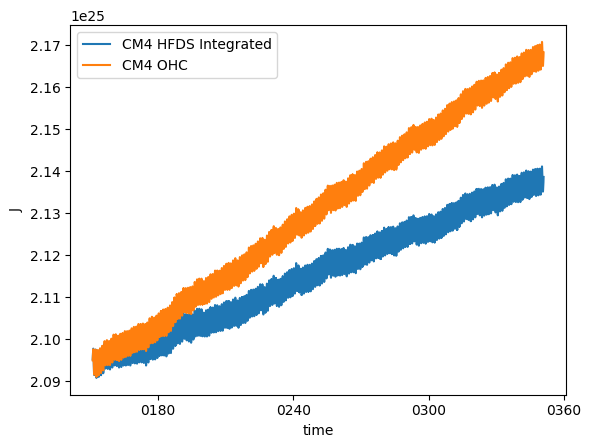

In [47]:
import matplotlib.pyplot as plt

(hfds_int+OHC.isel(time=0)).plot(label="CM4 HFDS Integrated")
# (OHC - OHC.isel(time=0)).plot(label="CM4 OHC")
(OHC).plot(label="CM4 OHC")
plt.ylabel("J")
plt.legend()
plt.show()

In [25]:
torch.tensor(ds.xh.to_numpy())

tensor([-299.7242, -299.4762, -299.2282,  ...,   59.5316,   59.7797,
          60.0277], dtype=torch.float64)

In [26]:
import torch
RAD_EARTH = 6371000
lat = torch.tensor(ds.yh.to_numpy())
lon = torch.tensor(ds.xh.to_numpy())


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [ ]:
# check data size
print("Total data size of CM4: ", ds.nbytes / 1e9, "GB")

In [14]:
import cftime

# Example DatetimeNoLeap object
no_leap_date = cftime.DatetimeNoLeap(150, 3, 29, 12, 0, 0)  # Replace with your own date

# Convert to DatetimeJulian
julian_date = cftime.DatetimeJulian(
    no_leap_date.year,
    no_leap_date.month,
    no_leap_date.day,
    no_leap_date.hour,
    no_leap_date.minute,
    no_leap_date.second,
)

julian_date

cftime.DatetimeJulian(150, 3, 29, 12, 0, 0, 0, has_year_zero=False)

In [4]:
ds.thetao.time.values

array([cftime.DatetimeNoLeap(151, 1, 6, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(151, 1, 11, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(151, 1, 16, 0, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeNoLeap(350, 12, 22, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(350, 12, 27, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(351, 1, 1, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)

In [9]:
data2.time.values

array([cftime.DatetimeJulian(1958, 1, 3, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(1958, 1, 8, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(1958, 1, 13, 12, 0, 0, 0, has_year_zero=False),
       ...,
       cftime.DatetimeJulian(2022, 12, 19, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2022, 12, 24, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2022, 12, 29, 12, 0, 0, 0, has_year_zero=False)],
      dtype=object)

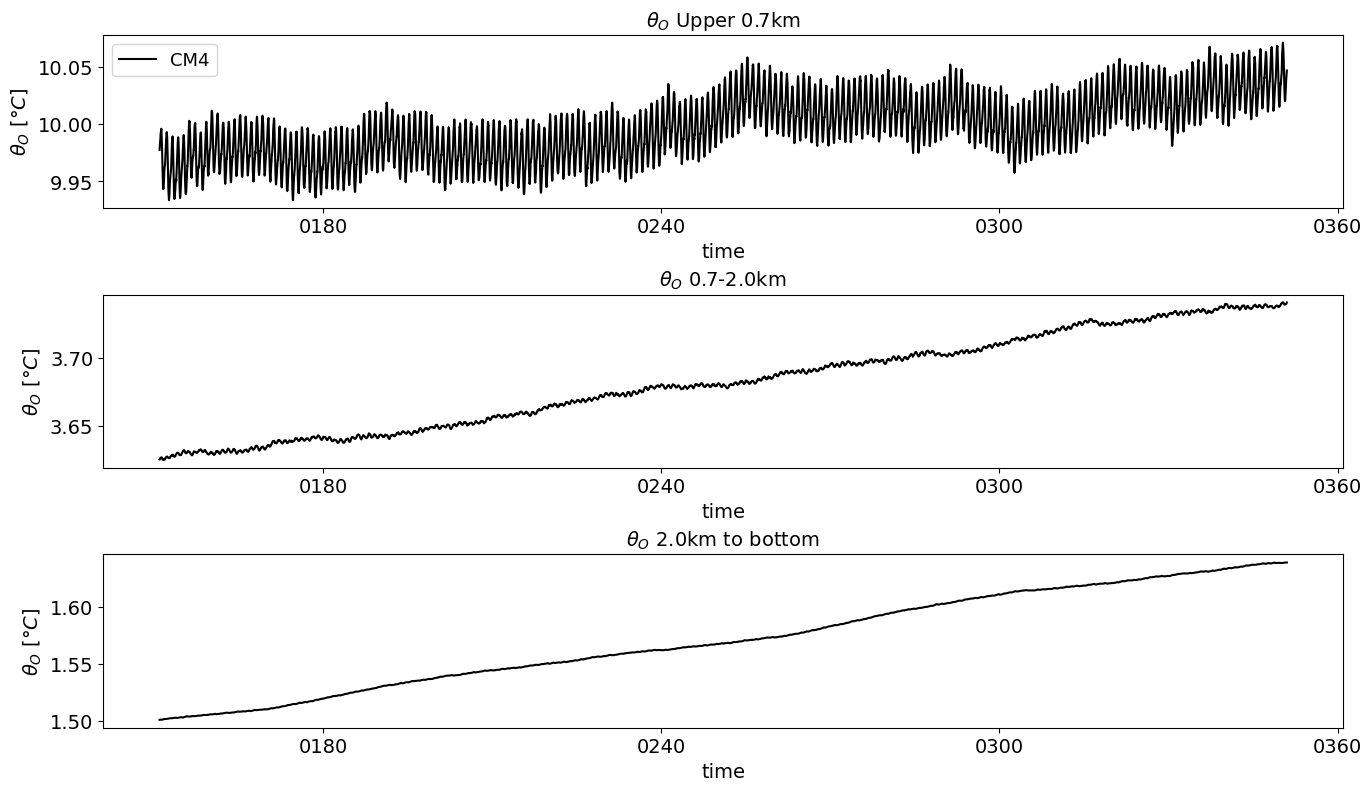

CPU times: user 4min 58s, sys: 38.8 s, total: 5min 36s
Wall time: 6min 1s


In [10]:
%%time
# All Sets - Depth - Thetao
import matplotlib.pyplot as plt

level_slices = [slice(None, 700), slice(700, 2000), slice(2000, None)]
# level_slices = [slice(None, 300), slice(300, 600), slice(600,)]
titles = [
    r"$\theta_O$ Upper 0.7km",
    r"$\theta_O$ 0.7-2.0km",
    r"$\theta_O$ 2.0km to bottom",
]

data = ds
data2

ds_input = xr.open_zarr(
    os.path.join("/pscratch/sd/s/suryad/data", "OM4_5daily_v0.2.1.zarr")
)
ds_full_groundtruth = ds_input.astype("float32")
data2 = ds_full_groundtruth

plt.rcdefaults()
plt.rcParams.update({"font.size": 14})
fig, axs = plt.subplots(
    3, 1, figsize=(16, 9), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)

for i, lev_slice in enumerate(level_slices):
    thetao = (
        (data["thetao"].sel(lev=lev_slice))
        .weighted(data["areacello"] * data["dz"])
        .mean(["x", "y", "lev"])
    )
    thetao = thetao.rename(r"$\theta_O$")
    thetao = thetao.assign_attrs(units=r"$\degree C$")
    thetao.plot(ax=axs[i], label="CM4", color="k")

    #     thetao = (data2['thetao'].sel(lev=lev_slice)).weighted(data2['areacello'] * data2['dz']).mean(['x', 'y', 'lev'])
    #     thetao = thetao.rename(r'$\theta_O$')
    #     thetao = thetao.assign_attrs(units=r'$\degree C$')
    #     thetao.plot(ax=axs[i], label='OM4', color='red')

    axs[i].set_title(titles[i], fontsize=14)
    if i == 0:
        axs[i].legend(fontsize=13)

plt.show()

Weighted Tests

In [1]:
import xarray as xr

In [10]:
# Create a dataset
ds = xr.Dataset(
    {
        "temperature": (["x", "y"], [[2, 2], [2, 2]]),
        "precipitation": (["x", "y"], [[0, 1], [2, 3]]),
    },
    coords={"x": [0, 1], "y": [0, 1]},
)
vol = xr.DataArray([[3, 2], [3, 2]], dims=["x", "y"], coords={"x": [0, 1], "y": [0, 1]})

In [17]:
ds.temperature.weighted(vol).mean()

<xarray.DataArray 'temperature' ()>
array(2.)

In [23]:
((ds.temperature) * (vol / vol.sum())).sum()

<xarray.DataArray ()>
array(2.)